In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

load_dotenv()

DB_HOST = os.getenv("SUPABASE_HOST")
DB_DB = os.getenv("SUPABASE_DB")
DB_USER = os.getenv("SUPABASE_USER")
DB_PASSWORD = quote_plus(os.getenv("SUPABASE_PASSWORD"))
DB_PORT = os.getenv("SUPABASE_PORT")

engine = sqlalchemy.create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_DB}",
    connect_args={"sslmode": "require"}
)

df = pd.read_sql('SELECT * FROM river_levels ORDER BY reading_time ASC', engine)
print(f"Total records: {len(df)}")
print(f"Date range: {df['reading_time'].min()} to {df['reading_time'].max()}")
print(f"\nStations: {df['station'].unique()}")
df.head()

Total records: 1319
Date range: 2026-03-22 13:00:00 to 2026-06-20 10:00:00

Stations: <ArrowStringArray>
['Hathnikund Barrage', 'Fatehgarh', 'Kalanaur']
Length: 3, dtype: str


,id,station,station_code,water_level,reading_time,fetched_at
0,7,Hathnikund Barrage,009-UYDDEL,333.53,2026-03-22 13:00:00,2026-06-20 10:15:30
1,515,Fatehgarh,038-UYDDEL,270.70,2026-03-22 13:00:00,2026-06-20 10:15:31
2,910,Kalanaur,010-UYDDEL,263.30,2026-03-22 13:00:00,2026-06-20 10:15:31
3,911,Kalanaur,010-UYDDEL,263.30,2026-03-22 18:00:00,2026-06-20 10:15:31
4,8,Hathnikund Barrage,009-UYDDEL,333.82,2026-03-22 18:00:00,2026-06-20 10:15:30


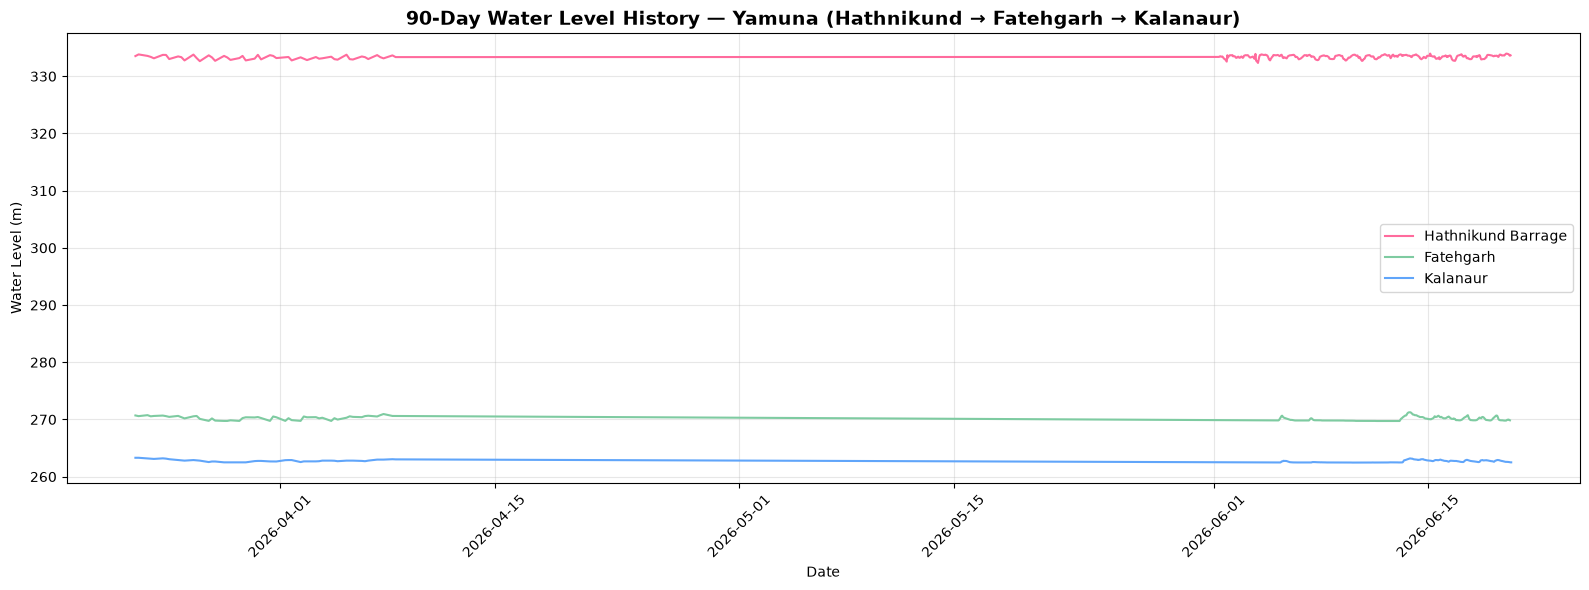

In [2]:
fig, ax = plt.subplots(figsize=(16, 6))

colors = {'Hathnikund Barrage': '#ff6b9d', 'Fatehgarh': '#7ecba1', 'Kalanaur': '#60a5fa'}

for station in df['station'].unique():
    station_data = df[df['station'] == station].sort_values('reading_time')
    ax.plot(station_data['reading_time'], station_data['water_level'], 
            label=station, color=colors[station], linewidth=1.5)

ax.set_title('90-Day Water Level History — Yamuna (Hathnikund → Fatehgarh → Kalanaur)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()